# Chapter 3 - Unsupervised Learning and Preprocessing

**Book:** Introduction to Machine Learning with Python  
**Authors:** Andreas C. Müller & Sarah Guido

Chapter ini membahas unsupervised learning dan preprocessing data.
Topik utama yang dibahas adalah scaling, dimensionality reduction,
dan clustering.

## 1. Chapter Overview

Unsupervised learning adalah metode machine learning yang bekerja
tanpa menggunakan target atau label.

Pada chapter ini dibahas:

1. Jenis-jenis unsupervised learning
2. Tantangan unsupervised learning
3. Preprocessing dan scaling
4. Principal Component Analysis (PCA)
5. Non-Negative Matrix Factorization (NMF)
6. t-SNE
7. K-Means clustering
8. Agglomerative clustering
9. DBSCAN
10. Perbandingan metode clustering

## 2. Unsupervised Learning

Pada supervised learning, model belajar menggunakan data dan target.
Sedangkan pada unsupervised learning, model hanya menggunakan data
tanpa target.

Tujuan utamanya adalah menemukan struktur atau pola tersembunyi
di dalam dataset.

Contoh:
- Mengelompokkan pelanggan berdasarkan karakteristiknya.
- Mengurangi jumlah fitur.
- Menemukan pola pada data yang belum memiliki label.

### Jenis Unsupervised Learning

Beberapa jenis utama:

- **Transformation / Dimensionality Reduction**
  Mengubah data menjadi representasi yang lebih sederhana.

- **Clustering**
  Mengelompokkan data berdasarkan kemiripan.

- **Manifold Learning**
  Mencari representasi berdimensi rendah dari data yang kompleks.

### Jenis Unsupervised Learning

Beberapa jenis utama:

- **Transformation / Dimensionality Reduction**
  Mengubah data menjadi representasi yang lebih sederhana.

- **Clustering**
  Mengelompokkan data berdasarkan kemiripan.

- **Manifold Learning**
  Mencari representasi berdimensi rendah dari data yang kompleks.

## 3. Challenges in Unsupervised Learning

Karena tidak memiliki label, hasil unsupervised learning lebih sulit
untuk dievaluasi.

Model dapat menemukan pola, tetapi belum tentu pola tersebut sesuai
dengan kebutuhan kita.

Oleh karena itu, hasil clustering atau dimensionality reduction
perlu dianalisis berdasarkan karakteristik data dan tujuan penggunaannya.

## 4. Preprocessing and Scaling

Preprocessing digunakan untuk mengubah data agar lebih sesuai
untuk digunakan oleh machine learning.

Salah satu preprocessing penting adalah scaling.

Scaling diperlukan karena beberapa algoritma sensitif terhadap
skala fitur, terutama algoritma yang menggunakan jarak seperti
KNN, K-Means, dan SVM.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Sebelum scaling:")
print(X_train[:3])

print("\nSetelah scaling:")
print(X_train_scaled[:3])

Sebelum scaling:
[[7.4 2.8 6.1 1.9]
 [7.7 2.8 6.7 2. ]
 [5.5 2.4 3.7 1. ]]

Setelah scaling:
[[ 1.79213839 -0.60238047  1.31532306  0.92095427]
 [ 2.14531053 -0.60238047  1.65320421  1.05135487]
 [-0.4446185  -1.50797259 -0.03620155 -0.25265117]]


`StandardScaler` mengubah data sehingga setiap fitur memiliki
rata-rata sekitar 0 dan standar deviasi sekitar 1.

Scaling hanya dilakukan dengan `fit` pada data training.
Data testing hanya menggunakan `transform`.

Hal ini dilakukan agar informasi dari data testing tidak masuk
ke proses training.

## 5. Effect of Preprocessing on Supervised Learning

Scaling dapat memengaruhi performa beberapa algoritma.

Algoritma yang menggunakan jarak atau besar koefisien sangat
dipengaruhi oleh skala fitur.

Sebaliknya, algoritma berbasis decision tree biasanya tidak
terlalu sensitif terhadap scaling.

In [2]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)
print("Accuracy tanpa scaling:", knn.score(X_test, y_test))

knn.fit(X_train_scaled, y_train)
print("Accuracy dengan scaling:", knn.score(X_test_scaled, y_test))

Accuracy tanpa scaling: 0.9736842105263158
Accuracy dengan scaling: 0.9210526315789473


## 6. Dimensionality Reduction

Dimensionality reduction bertujuan mengurangi jumlah fitur
tanpa kehilangan terlalu banyak informasi penting.

Manfaatnya antara lain:

- Mempermudah visualisasi.
- Mengurangi kompleksitas data.
- Mempercepat proses machine learning.
- Membantu mengurangi noise atau fitur yang tidak terlalu penting.

Pada chapter ini digunakan:
- PCA
- NMF
- t-SNE

## 7. Principal Component Analysis (PCA)

PCA mengubah fitur asli menjadi beberapa komponen baru
yang disebut principal components.

Komponen pertama mempertahankan variasi terbesar dalam data,
kemudian komponen berikutnya mempertahankan variasi terbesar
berikutnya.

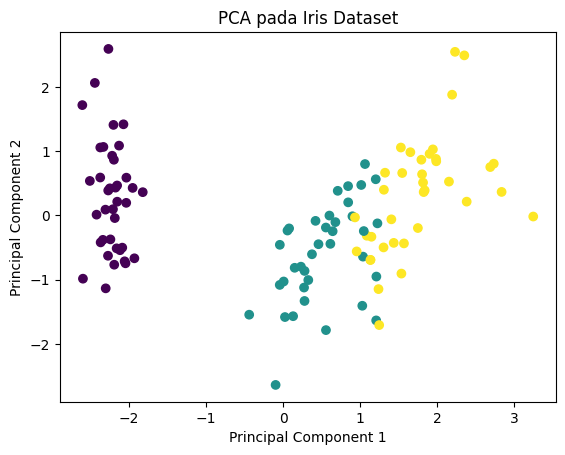

Explained variance ratio: [0.73911238 0.22125712]


In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA pada Iris Dataset")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

Dengan PCA, data Iris yang awalnya memiliki 4 fitur
direduksi menjadi 2 fitur.

`explained_variance_ratio_` menunjukkan seberapa besar variasi
data yang dapat dijelaskan oleh setiap komponen.

## 8. Non-Negative Matrix Factorization (NMF)

NMF merupakan metode dimensionality reduction yang bekerja
pada data dengan nilai non-negatif.

NMF mencoba merepresentasikan data sebagai kombinasi dari
beberapa komponen non-negatif.

Metode ini dapat digunakan untuk menemukan pola atau bagian
penting dari suatu dataset.

In [4]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler

X_positive = MinMaxScaler().fit_transform(X)

nmf = NMF(n_components=2, random_state=42, max_iter=1000)

X_nmf = nmf.fit_transform(X_positive)

print("Shape data awal :", X.shape)
print("Shape setelah NMF:", X_nmf.shape)

Shape data awal : (150, 4)
Shape setelah NMF: (150, 2)


## 9. t-SNE

t-SNE merupakan metode dimensionality reduction yang banyak
digunakan untuk visualisasi data berdimensi tinggi.

Tujuannya adalah mempertahankan hubungan atau kedekatan antar
data ketika diproyeksikan ke dimensi yang lebih rendah.

t-SNE terutama berguna untuk eksplorasi dan visualisasi,
bukan sebagai metode preprocessing umum untuk semua model.

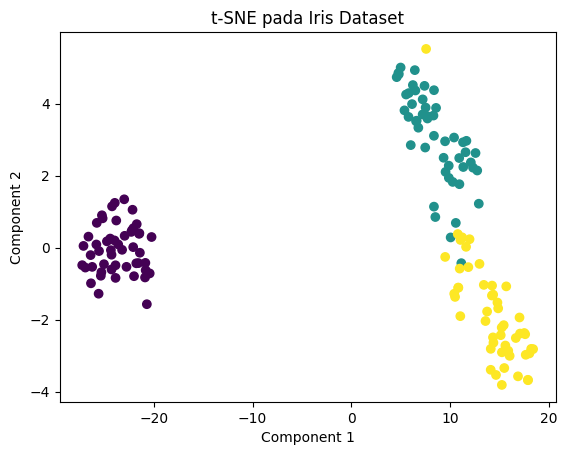

In [5]:
from sklearn.manifold import TSNE

X_tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
).fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
plt.title("t-SNE pada Iris Dataset")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## 10. Clustering

Clustering adalah teknik untuk membagi data menjadi beberapa
kelompok berdasarkan kemiripan.

Berbeda dengan classification, clustering tidak membutuhkan
label pada saat training.

Pada chapter ini digunakan tiga metode:

1. K-Means
2. Agglomerative Clustering
3. DBSCAN

## 11. K-Means Clustering

K-Means membagi data menjadi sejumlah cluster yang telah
ditentukan sebelumnya.

Proses sederhananya:

1. Menentukan jumlah cluster.
2. Menentukan pusat cluster.
3. Mengelompokkan data berdasarkan pusat terdekat.
4. Memperbarui pusat cluster.
5. Mengulangi proses sampai stabil.

## 12. Agglomerative Clustering

Agglomerative clustering merupakan hierarchical clustering
yang dimulai dari setiap data sebagai cluster tersendiri.

Cluster yang paling dekat kemudian digabung secara bertahap
hingga mencapai jumlah cluster yang diinginkan.

## 13. DBSCAN

DBSCAN mengelompokkan data berdasarkan kepadatan.

Keuntungan DBSCAN adalah dapat menemukan cluster dengan bentuk
yang tidak beraturan dan dapat mengidentifikasi data yang dianggap
sebagai noise.

Berbeda dengan K-Means, jumlah cluster tidak perlu ditentukan
secara langsung.

## 14. Comparing Clustering Algorithms

Ketiga algoritma memiliki karakteristik yang berbeda:

| Metode | Karakteristik |
|---|---|
| K-Means | Sederhana dan membutuhkan jumlah cluster |
| Agglomerative | Membentuk hierarchical clusters |
| DBSCAN | Berdasarkan kepadatan dan dapat mendeteksi noise |

Tidak ada satu algoritma yang selalu cocok untuk semua dataset.
Pemilihan metode bergantung pada bentuk dan karakteristik data.

## 15. Ringkasan Metode

### Preprocessing
Digunakan untuk mempersiapkan data sebelum masuk ke model.

### PCA
Mengurangi dimensi dengan mempertahankan variasi data sebanyak mungkin.

### NMF
Membentuk representasi data berdasarkan komponen non-negatif.

### t-SNE
Digunakan terutama untuk visualisasi data berdimensi tinggi.

### K-Means
Mengelompokkan data berdasarkan jarak terhadap pusat cluster.

### Agglomerative
Membangun cluster secara bertahap melalui proses penggabungan.

### DBSCAN
Mengelompokkan data berdasarkan kepadatan dan dapat menemukan noise.

## 16. Results and Analysis

Pada eksperimen ini, preprocessing menunjukkan bahwa scaling
dapat memengaruhi algoritma yang menggunakan perhitungan jarak.

PCA, NMF, dan t-SNE dapat mengubah data berdimensi tinggi
menjadi representasi yang lebih sederhana.

Pada clustering, K-Means membutuhkan jumlah cluster sejak awal,
Agglomerative membentuk cluster secara hierarki, sedangkan DBSCAN
menggunakan kepadatan data dan dapat mengidentifikasi noise.

Hasil clustering juga dapat berbeda karena setiap algoritma
menggunakan pendekatan yang berbeda.

## 17. Chapter Summary

Chapter ini membahas unsupervised learning dan preprocessing.

Hal-hal penting yang dipelajari:

- Unsupervised learning bekerja tanpa target/label.
- Scaling penting untuk algoritma yang sensitif terhadap jarak.
- PCA digunakan untuk dimensionality reduction.
- NMF menghasilkan representasi berdasarkan komponen non-negatif.
- t-SNE berguna untuk visualisasi data berdimensi tinggi.
- K-Means mengelompokkan data berdasarkan pusat cluster.
- Agglomerative menggunakan pendekatan hierarchical clustering.
- DBSCAN menggunakan kepadatan dan dapat mendeteksi noise.

Pemilihan metode harus disesuaikan dengan karakteristik dataset
dan tujuan analisis.

## Key Takeaways

1. Data perlu dipersiapkan sebelum digunakan dalam machine learning.
2. Scaling dapat berpengaruh besar pada algoritma tertentu.
3. Dimensionality reduction membantu menyederhanakan data.
4. Clustering dapat menemukan kelompok tanpa menggunakan label.
5. Setiap algoritma clustering memiliki kelebihan dan karakteristik
   yang berbeda.
6. Hasil unsupervised learning perlu dianalisis karena tidak memiliki
   target yang dapat digunakan sebagai acuan langsung.

## References

1. Andreas C. Müller and Sarah Guido,
   *Introduction to Machine Learning with Python*,
   O'Reilly Media, 2016.

2. Scikit-learn Documentation:
   https://scikit-learn.org/

3. Official author repository:
   https://github.com/amueller/introduction_to_ml_with_python